##  DataFrame как структура данных

DataFrame является двумерной структурой и представляется в виде таблицы, в которой есть строки и столбцы: столбцами в DataFrame выступают объекты Series, а строки формируются из их элементов. Также в DataFrame есть метки (индексы), которые соответствуют каждой строке таблицы.

## Создание DataFrame

DataFrame создаётся с помощью функции pd.DataFrame(). Так же, как и для Series, для создания объектов DataFrame есть несколько способов:

Способ 1

Самый простой способ создания DataFrame — из словаря, ключами которого являются имена столбцов будущей таблицы, а значениями — списки, в которых хранится содержимое этих столбцов:

In [5]:
import pandas as pd
countries_df = pd.DataFrame({
    'country': ['Англия', 'Канада', 'США', 'Россия', 'Украина', 'Беларусь', 'Казахстан'],
    'population': [56.29, 38.05, 322.28, 146.24, 45.5, 9.5, 17.04],
    'area': [133396, 9984670, 9826630, 17125191, 603628, 207600, 2724902]
})
countries_df.index = ['UK', 'CA', 'US', 'RU', 'UA', 'BY', 'KZ']
display(countries_df)

,country,population,area
UK,Англия,56.29,133396
CA,Канада,38.05,9984670
US,США,322.28,9826630
RU,Россия,146.24,17125191
UA,Украина,45.50,603628
BY,Беларусь,9.50,207600
KZ,Казахстан,17.04,2724902


Способ 2

Также DataFrame можно создать из вложенного списка, внутренние списки которого будут являться строками новой таблицы:

In [6]:
countries_df = pd.DataFrame(
    data = [
        ['Англия', 56.29, 133396],
        ['Канада', 38.05, 9984670],
        ['США', 322.28, 9826630],
        ['Россия', 146.24, 17125191],
        ['Украина', 45.5, 603628],
        ['Беларусь', 9.5, 207600],
        ['Казахстан', 17.04, 2724902]
    ],
    columns= ['country', 'population', 'area'],
    index = ['UK', 'CA', 'US', 'RU', 'UA', 'BY', 'KZ']
)
display(countries_df)

,country,population,area
UK,Англия,56.29,133396
CA,Канада,38.05,9984670
US,США,322.28,9826630
RU,Россия,146.24,17125191
UA,Украина,45.50,603628
BY,Беларусь,9.50,207600
KZ,Казахстан,17.04,2724902


## Axis в DataFrame

При работе с Pandas важно уметь указывать направление работы метода, который используется. Для этого вводится понятие axis (ось, координата). Движение по строкам в таблице обозначается axis с индексом 0, а движение по столбцам — axis с индексом 1.

Данный параметр заложен во все методы, которые могут работать в двух направлениях и по умолчанию в большинстве из них axis=0, то есть они выполняют операции со строками, если не задавать axis вручную.

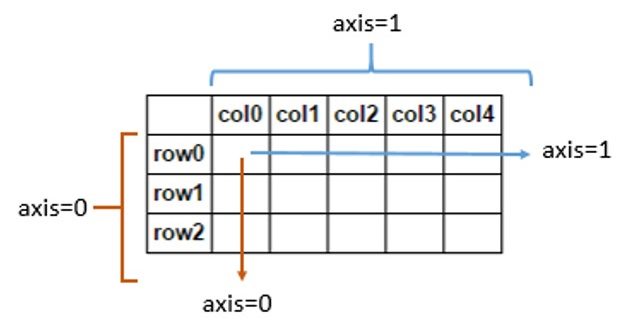

Рассмотрим разницу в результатах работы методов в зависимости от параметра axis на примере использования метода DataFrame mean() — вычисление среднего по таблице.

Считаем среднее по строкам (axis = 0) в каждом столбце:

In [7]:
countries_df.mean(axis=0, numeric_only=True)

population    9.070000e+01
area          5.800860e+06
dtype: float64

В данном случае среднее было рассчитано по строкам для столбцов population и area.

Обратите внимание на то, что так как не все столбцы в нашей таблице являются числовыми, то нам необходимо установить параметр numeric_only в значение True (вести расчёт только по числовым столбцам). Это делается для того, чтобы не получать предупреждений (warnings).

Считаем среднее по столбцам (axis = 1) в каждой строке:

In [8]:
countries_df.mean(axis=1, numeric_only=True)

UK      66726.145
CA    4992354.025
US    4913476.140
RU    8562668.620
UA     301836.750
BY     103804.750
KZ    1362459.520
dtype: float64

Здесь среднее было рассчитано по числовым столбцам для каждой строки в таблице.

## Доступ к данным в DataFrame

Доступ к столбцу можно получить разными способами:

Можно обратиться к DataFrame по имени столбца через точку:

In [9]:
countries_df.population

UK     56.29
CA     38.05
US    322.28
RU    146.24
UA     45.50
BY      9.50
KZ     17.04
Name: population, dtype: float64

Однако использование такого способа возможно только тогда, когда имя столбца указано без пробелов.

Другой вариант — обратиться к DataFrame по индексу и указать имя столбца:

In [10]:
countries_df['population']

UK     56.29
CA     38.05
US    322.28
RU    146.24
UA     45.50
BY      9.50
KZ     17.04
Name: population, dtype: float64

Примечание. Обратите внимание, что, как и ожидалось, при обращении к столбцу DataFrame мы получаем объект Series с именем, соответствующим имени столбца. Удостовериться в этом можно с помощью функции type():

In [11]:
type(countries_df.population)

pandas.Series

Для того чтобы получить доступ к ячейкам таблицы, используются уже знакомые нам loc и iloc.

При этом, в соответствии с механизмом работы axis, при обращении к DataFrame по индексам с помощью loc (iloc) первым индексом указывается индекс (порядковый номер), соответствующий строкам, а вторым — имя (порядковый номер) столбца.

Получим площадь Великобритании:

In [12]:
countries_df.loc['UK', 'area']

np.int64(133396)

Получим население и площадь, соответствующие России:

In [13]:
countries_df.loc['RU', ['population', 'area']]

population         146.24
area          17125191.00
Name: RU, dtype: float64

Сделаем вырезку из таблицы и получим информацию о населении и площади, соответствующую Украине, Беларуси и Казахстану:

In [14]:
countries_df.loc[['UA', 'BY', 'KZ'],['population', 'area']]

,population,area
UA,45.50,603628
BY,9.50,207600
KZ,17.04,2724902


In [15]:
countries_df.iloc[4:8, 1:3]

,population,area
UA,45.50,603628
BY,9.50,207600
KZ,17.04,2724902
